## Previsão Aliens

<h2>Imports</h2>

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import kpss, adfuller


<h2>Loading Data</h2>

In [11]:
raw_ts = pd.read_csv(
    'ufo_sightings_scrubbed.csv',
    usecols=['datetime'],
    index_col='datetime',
    parse_dates=['datetime'],
    date_format='%Y-%m-%d %H:%M:%S'
)

<h2>Transforming Data</h2>

In [12]:
ts = raw_ts.resample('ME').size()

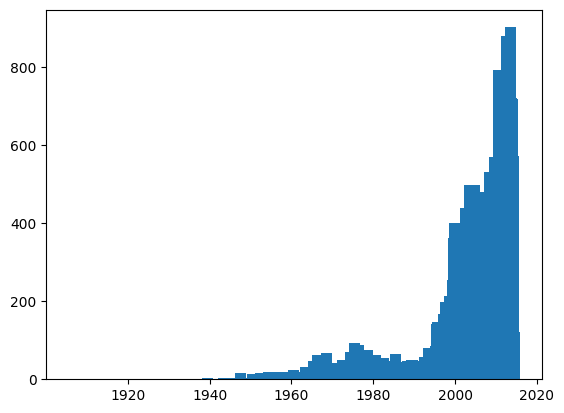

<Figure size 6400x800 with 0 Axes>

In [13]:
plt.bar(ts.index, ts.values, width=1000)
plt.figure(figsize=(64,8))
plt.show()

## ACF e PACF

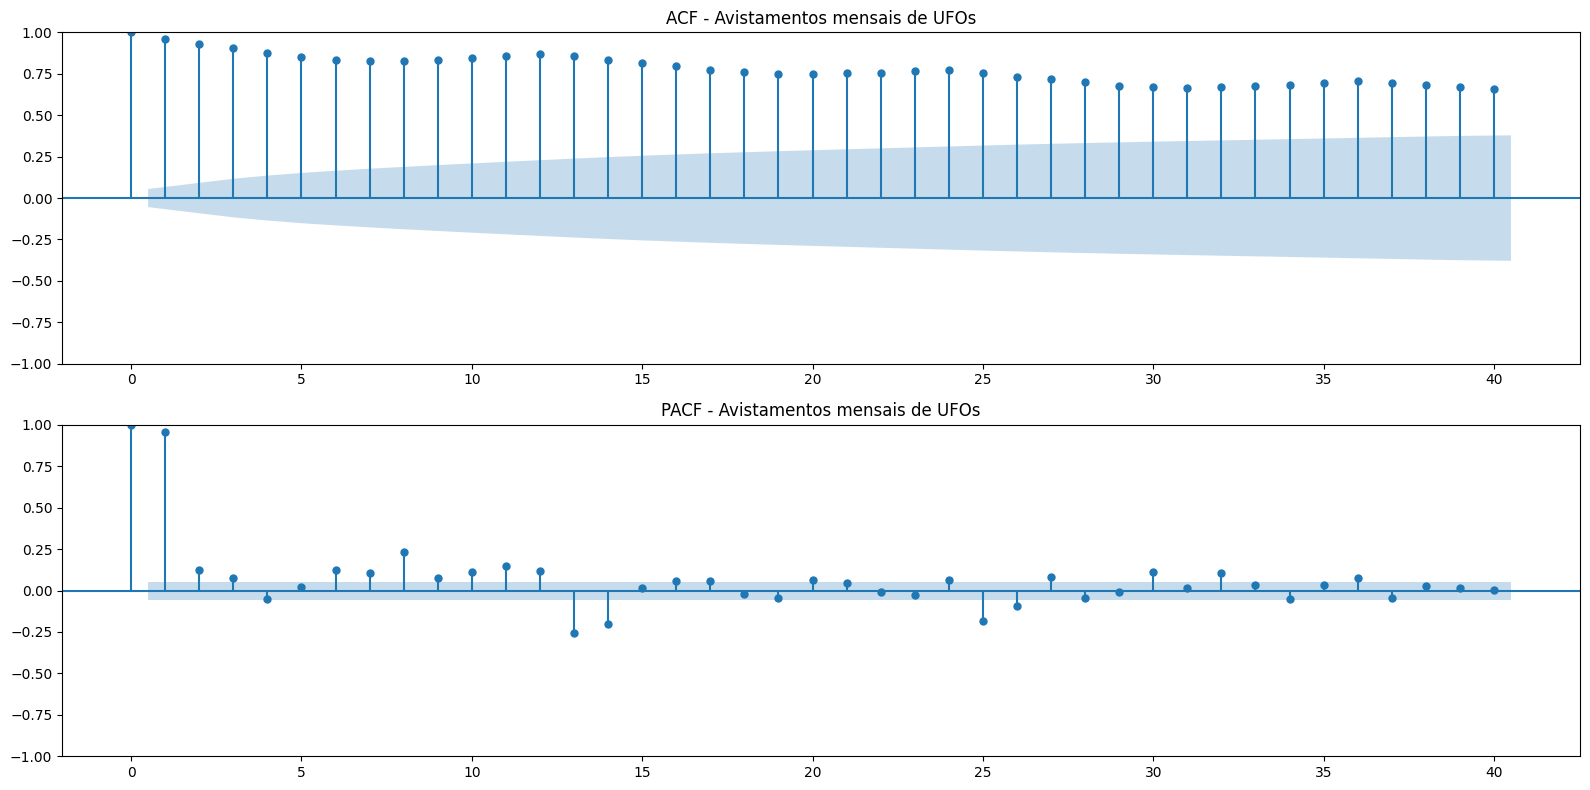

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

plot_acf(ts, lags=40, ax=axes[0], title='ACF - Avistamentos mensais de UFOs')
plot_pacf(ts, lags=40, ax=axes[1], title='PACF - Avistamentos mensais de UFOs')

plt.tight_layout()
plt.show()

# Decomposição STL

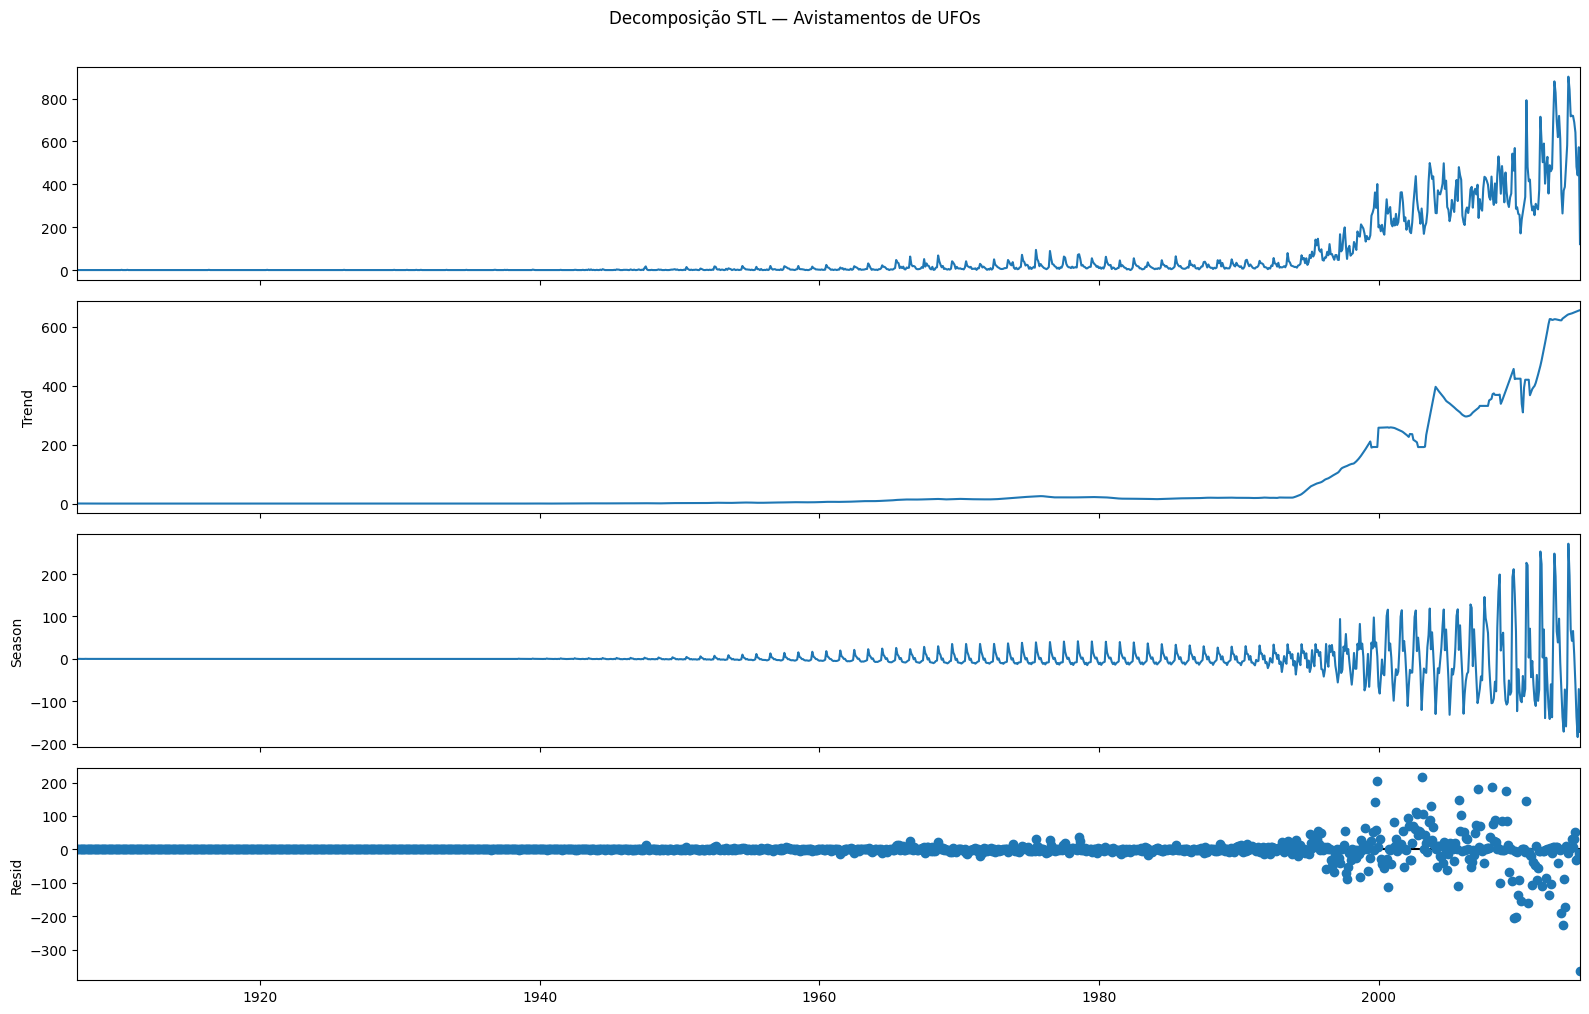

In [15]:
stl = STL(ts, period=12, seasonal=13, robust=True)
result = stl.fit()

fig = result.plot()
fig.set_size_inches(16, 10)
fig.suptitle('Decomposição STL — Avistamentos de UFOs', y=1.01)
plt.tight_layout()
plt.show()

In [16]:
trend, seasonal, resid = result.trend, result.seasonal, result.resid

F_trend = max(0, 1 - resid.var() / (trend + resid).var())
F_seasonal = max(0, 1 - resid.var() / (seasonal + resid).var())

print(f'Força de tendência   (F_T): {F_trend:.3f}')
print(f'Força de sazonalidade (F_S): {F_seasonal:.3f}')

Força de tendência   (F_T): 0.954
Força de sazonalidade (F_S): 0.582


# ADF

In [19]:
adf_ts = adfuller(ts.dropna())

print("Estatística ADF:", adf_ts[0])
print("p-valor:", adf_ts[1])
print("Valores críticos:", adf_ts[4])

Estatística ADF: 4.266907111636351
p-valor: 1.0
Valores críticos: {'1%': np.float64(-3.4355217427788793), '5%': np.float64(-2.8638238726872296), '10%': np.float64(-2.5679859566283705)}


# KPSS

In [20]:
kpss_ts = kpss(ts.dropna(), regression='c', nlags='auto')

print("KPSS Estatística:", kpss_ts[0])
print("p-valor:", kpss_ts[1])
print("Valores críticos:", kpss_ts[3])

KPSS Estatística: 3.009411799789264
p-valor: 0.01
Valores críticos: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\joaovargas-ieg\AppData\Local\Temp\ipykernel_39252\2451046276.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_ts = kpss(ts.dropna(), regression='c', nlags='auto')
